In [1]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split



In [87]:
dose_info_file_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DoseParams.xlsx"
#dose_info_file_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/extracted_dose_16_5_2022_hendrike.csv"


#df_dose = pd.read_excel(dose_info_file_path)
df_dose = pd.read_excel(dose_info_file_path)

mean_cols = [x for x in df_dose.columns if "Dmean" in x]
df_dose_means = df_dose[['PatID'] + mean_cols]
print(mean_cols)

#df_dose["PatID"] = [str(item).zfill(7) for item in df_dose["PatID"]]
#df_dose = df_dose.rename(columns={"PatID": "PatientID"})

# df_dose = df_dose.drop(columns=["PatID"])
# df_dose.insert(0, "PatientID", df_dose.pop("PatientID"))
"""
df_dose = pd.read_csv(dose_info_file_path, delimiter=';', index_col=None, decimal=",")
df_dose["PatientID"] = [str(item).zfill(7) for item in df_dose["PatientID"]]
#df_dose['OralCavity_Ext_meandose']
"""

['Parotid_R_Dmean', 'Parotid_L_Dmean', 'BuccalMucosa_Dmean', 'BuccalMucosa_L_Dmean', 'BuccalMucosa_R_Dmean', 'Crico_Dmean', 'Esophagus_Cerv_Dmean', 'OralCavity_Ext_Dmean', 'PCM_Dmean', 'PCM_Inf_Dmean', 'PCM_Med_Dmean', 'PCM_Sup_Dmean', 'Parotid_Dmean', 'Submandibular_Dmean', 'Submandibular_L_Dmean', 'Submandibular_R_Dmean', 'Supraglottic_Dmean']


'\ndf_dose = pd.read_csv(dose_info_file_path, delimiter=\';\', index_col=None, decimal=",")\ndf_dose["PatientID"] = [str(item).zfill(7) for item in df_dose["PatientID"]]\n#df_dose[\'OralCavity_Ext_meandose\']\n'

In [89]:
dose_info_file_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/DoseParams_Now.xlsx"
#dose_info_file_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/extracted_dose_16_5_2022_hendrike.csv"


#df_dose = pd.read_excel(dose_info_file_path)
df_dose = pd.read_excel(dose_info_file_path)

mean_cols = [x for x in df_dose.columns if "Davg" in x]
df_dose_means = df_dose[['PatID'] + mean_cols]
print(mean_cols)

['Parotid_RDavg', 'Parotid_LDavg', 'BuccalMucosaDavg', 'BuccalMucosa_LDavg', 'BuccalMucosa_RDavg', 'CricoDavg', 'Esophagus_CervDavg', 'OralCavity_ExtDavg', 'PCMDavg', 'PCM_InfDavg', 'PCM_MedDavg', 'PCM_SupDavg', 'ParotidDavg', 'SubmandibularDavg', 'Submandibular_LDavg', 'Submandibular_RDavg', 'SupraglotticDavg', 'ExternalDavg']


In [84]:
dose_info_file_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/MDACC/DoseParams_MDACC.xlsx"
df_dose = pd.read_excel(dose_info_file_path)

mean_cols = [x for x in df_dose.columns if "Davg" in x]
df_dose_means = df_dose[['PatID'] + mean_cols]
mean_cols

['Parotid_RDavg',
 'Parotid_LDavg',
 'BuccalMucosaDavg',
 'BuccalMucosa_LDavg',
 'BuccalMucosa_RDavg',
 'CricoDavg',
 'Esophagus_CervDavg',
 'OralCavity_ExtDavg',
 'PCMDavg',
 'PCM_InfDavg',
 'PCM_MedDavg',
 'PCM_SupDavg',
 'ParotidDavg',
 'SubmandibularDavg',
 'Submandibular_LDavg',
 'Submandibular_RDavg',
 'SupraglotticDavg',
 'BrainDavg',
 'MandibleDavg',
 'Arytenoid_LDavg',
 'Arytenoid_RDavg',
 'BrainstemDavg',
 'ExternalDavg']

In [73]:
parotid_cols = [x for x in df_dose.columns if "Parotid" in x]
mean_cols = [x for x in df_dose.columns if "mean" in x]


df_dose_means = df_dose[['PatientID'] + mean_cols]

In [74]:
df_dose_means

,PatientID,Parotid_L_meandose,Parotid_R_meandose,Parotid_meandose,Submandibular_L_meandose,Submandibular_R_meandose,Submandibular_meandose,PCM_Sup_meandose,PCM_Med_meandose,PCM_Inf_meandose,Crico_meandose,Supraglottic_meandose,OralCavity_Ext_meandose,BuccalMucosa_L_meandose,BuccalMucosa_R_meandose,BuccalMucosa_meandose,TongueTop_meandose,External_meandose,PCM_meandose,Esophagus_Cerv_meandose
0,0005680,0.310044,0.344783,0.326766,1.010520,1.015497,1.013139,0.544177,8.848484,50.582483,21.297612,35.565953,0.555905,0.282278,0.289381,0.285991,0.318988,2.043092,11.305783,1.338918
1,0020715,26.432968,17.744559,22.460510,68.835097,46.414356,58.693037,66.051506,38.330428,16.787087,14.327347,24.664699,56.676119,69.568291,33.253434,51.579341,59.432229,12.602244,47.667319,11.597400
2,0021879,33.259027,30.598383,31.789204,61.041476,55.280976,57.937461,67.438013,53.527220,25.805898,29.623516,23.218957,49.755277,42.774188,43.399178,43.086601,42.618870,15.105915,51.503184,24.868150
3,0052277,32.082955,33.453960,32.809701,60.431295,63.251656,62.009299,58.868152,41.697859,30.940294,27.887455,27.290791,63.163352,45.434199,56.854678,51.666819,55.538533,11.907386,46.078026,27.510634
4,0059896,27.249700,36.432793,31.979660,57.944604,67.497344,62.717922,60.347738,52.272689,29.809969,24.061151,44.929507,44.783982,55.105660,32.541407,43.846077,34.274179,11.861039,47.536148,21.815486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1163,9949620,0.072337,0.095805,0.084342,1.208355,1.016414,1.111487,0.249860,8.676321,50.042890,28.391910,48.747977,0.205955,0.028627,0.034436,0.031420,0.017626,2.171772,12.491105,3.796289
1164,9956433,31.366234,19.478872,25.588652,68.694768,49.955012,59.141604,60.431882,46.646579,32.985069,30.268910,36.174795,52.527735,57.727289,35.505397,47.009404,48.722470,17.262427,50.415595,33.625128
1165,9967950,25.801497,42.287867,33.750455,61.519751,70.136110,66.352219,66.751292,57.565897,42.692910,44.911113,49.529050,66.434764,51.000655,69.103268,60.529150,61.572888,15.275863,57.800654,37.477199
1166,9977441,17.205799,17.151161,17.182238,41.056238,45.278306,43.205165,36.498781,47.614415,59.675797,44.928786,56.509973,17.120248,17.423711,14.400799,15.853688,8.043674,10.560832,44.772596,30.226589


In [75]:
mean_cols

['Parotid_L_meandose',
 'Parotid_R_meandose',
 'Parotid_meandose',
 'Submandibular_L_meandose',
 'Submandibular_R_meandose',
 'Submandibular_meandose',
 'PCM_Sup_meandose',
 'PCM_Med_meandose',
 'PCM_Inf_meandose',
 'Crico_meandose',
 'Supraglottic_meandose',
 'OralCavity_Ext_meandose',
 'BuccalMucosa_L_meandose',
 'BuccalMucosa_R_meandose',
 'BuccalMucosa_meandose',
 'TongueTop_meandose',
 'External_meandose',
 'PCM_meandose',
 'Esophagus_Cerv_meandose']

In [76]:
df_dose_means

,PatientID,Parotid_L_meandose,Parotid_R_meandose,Parotid_meandose,Submandibular_L_meandose,Submandibular_R_meandose,Submandibular_meandose,PCM_Sup_meandose,PCM_Med_meandose,PCM_Inf_meandose,Crico_meandose,Supraglottic_meandose,OralCavity_Ext_meandose,BuccalMucosa_L_meandose,BuccalMucosa_R_meandose,BuccalMucosa_meandose,TongueTop_meandose,External_meandose,PCM_meandose,Esophagus_Cerv_meandose
0,0005680,0.310044,0.344783,0.326766,1.010520,1.015497,1.013139,0.544177,8.848484,50.582483,21.297612,35.565953,0.555905,0.282278,0.289381,0.285991,0.318988,2.043092,11.305783,1.338918
1,0020715,26.432968,17.744559,22.460510,68.835097,46.414356,58.693037,66.051506,38.330428,16.787087,14.327347,24.664699,56.676119,69.568291,33.253434,51.579341,59.432229,12.602244,47.667319,11.597400
2,0021879,33.259027,30.598383,31.789204,61.041476,55.280976,57.937461,67.438013,53.527220,25.805898,29.623516,23.218957,49.755277,42.774188,43.399178,43.086601,42.618870,15.105915,51.503184,24.868150
3,0052277,32.082955,33.453960,32.809701,60.431295,63.251656,62.009299,58.868152,41.697859,30.940294,27.887455,27.290791,63.163352,45.434199,56.854678,51.666819,55.538533,11.907386,46.078026,27.510634
4,0059896,27.249700,36.432793,31.979660,57.944604,67.497344,62.717922,60.347738,52.272689,29.809969,24.061151,44.929507,44.783982,55.105660,32.541407,43.846077,34.274179,11.861039,47.536148,21.815486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1163,9949620,0.072337,0.095805,0.084342,1.208355,1.016414,1.111487,0.249860,8.676321,50.042890,28.391910,48.747977,0.205955,0.028627,0.034436,0.031420,0.017626,2.171772,12.491105,3.796289
1164,9956433,31.366234,19.478872,25.588652,68.694768,49.955012,59.141604,60.431882,46.646579,32.985069,30.268910,36.174795,52.527735,57.727289,35.505397,47.009404,48.722470,17.262427,50.415595,33.625128
1165,9967950,25.801497,42.287867,33.750455,61.519751,70.136110,66.352219,66.751292,57.565897,42.692910,44.911113,49.529050,66.434764,51.000655,69.103268,60.529150,61.572888,15.275863,57.800654,37.477199
1166,9977441,17.205799,17.151161,17.182238,41.056238,45.278306,43.205165,36.498781,47.614415,59.675797,44.928786,56.509973,17.120248,17.423711,14.400799,15.853688,8.043674,10.560832,44.772596,30.226589


In [77]:
processed_images_dataset_path = '//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/preprocessed/dataset_full'
all_patient_folders = next(os.walk(processed_images_dataset_path))[1]

In [78]:
missing_dose = [p for p in all_patient_folders if p not in list(df_dose['PatientID'])]
missing_dose

[]

In [36]:
len(all_patient_folders)

1167

In [37]:
list(df_dose['PatID'])

[5680,
 20715,
 21879,
 52277,
 59896,
 64747,
 66593,
 70426,
 79378,
 84356,
 92560,
 103413,
 113306,
 137534,
 143253,
 153056,
 153939,
 156646,
 163115,
 163517,
 170637,
 182246,
 185080,
 191693,
 194349,
 194775,
 197871,
 213240,
 222234,
 249713,
 253090,
 260377,
 262827,
 263641,
 263964,
 263980,
 267385,
 276627,
 287554,
 292263,
 298536,
 303865,
 309877,
 314815,
 315925,
 321403,
 330684,
 334826,
 338902,
 339381,
 339740,
 340294,
 343548,
 345451,
 359912,
 385303,
 400509,
 401057,
 402490,
 407063,
 409363,
 412104,
 453763,
 455447,
 459618,
 484397,
 492526,
 507025,
 508784,
 516456,
 517608,
 539218,
 548046,
 552777,
 558365,
 561117,
 563941,
 574415,
 585519,
 587984,
 598217,
 600823,
 603538,
 608167,
 610745,
 611128,
 617129,
 625979,
 630756,
 636860,
 642069,
 646031,
 652285,
 662515,
 662610,
 665360,
 669746,
 676250,
 688318,
 694884,
 701196,
 707556,
 721838,
 748037,
 754702,
 756493,
 758372,
 765200,
 767274,
 774481,
 777661,
 786256,
 788

In [3]:
cols = list(df_dose.columns)

for c in cols: print(c)

PatID
Parotid_R_Dmean
Parotid_R_D1
Parotid_R_D2
Parotid_R_D5
Parotid_R_D10
Parotid_R_D15
Parotid_R_D20
Parotid_R_D25
Parotid_R_D30
Parotid_R_D35
Parotid_R_D40
Parotid_R_D45
Parotid_R_D50
Parotid_R_D55
Parotid_R_D60
Parotid_R_D65
Parotid_R_D70
Parotid_R_D75
Parotid_R_D80
Parotid_R_D85
Parotid_R_D90
Parotid_R_D95
Parotid_R_D98
Parotid_R_D99
Parotid_R_V1
Parotid_R_V2
Parotid_R_V5
Parotid_R_V10
Parotid_R_V15
Parotid_R_V20
Parotid_R_V25
Parotid_R_V30
Parotid_R_V35
Parotid_R_V40
Parotid_R_V45
Parotid_R_V50
Parotid_R_V55
Parotid_R_V60
Parotid_R_V65
Parotid_R_V70
Parotid_R_V75
Parotid_R_V80
Parotid_L_Dmean
Parotid_L_D1
Parotid_L_D2
Parotid_L_D5
Parotid_L_D10
Parotid_L_D15
Parotid_L_D20
Parotid_L_D25
Parotid_L_D30
Parotid_L_D35
Parotid_L_D40
Parotid_L_D45
Parotid_L_D50
Parotid_L_D55
Parotid_L_D60
Parotid_L_D65
Parotid_L_D70
Parotid_L_D75
Parotid_L_D80
Parotid_L_D85
Parotid_L_D90
Parotid_L_D95
Parotid_L_D98
Parotid_L_D99
Parotid_L_V1
Parotid_L_V2
Parotid_L_V5
Parotid_L_V10
Parotid_L_V15
Parotid_

## File Paths & Settings


In [22]:
# CITOR_REDCAP file: where all the clinical variables and toxicity endpoints are sourced
REDCAP_dir = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/CITOR_REDCAP_clinical_data_important_variables_combined.xlsx"
dicoms_path = '//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/DLC_complete/'   # ideally, this is a folder that contains all of the processed image data files



target = "M12"                    # target for the multitox model ["M06", "M12", "M18"]
open_geexcludeerd_sheet = False   # whether to include the second page of the CITOR_RECAP file

also_include_M24 = False          # whether to process the "M24" columns as well (Dysphagia is missing it, all the other toxicities have it)

stratified_sampling_columns = ["Sex", "CT+C_available", "CT_Artefact", "Loctum2", "Photons"]  # !!! The target toxicity columns are also always included !!!!

### Open the CITOR_REDCAP spreadsheet

In [80]:

"""
LOAD DATA
"""

dataset_df = pd.read_excel(REDCAP_dir)

# this condition will include the first two sheets in the REDCAP excel file, otherwise, just the first is used
if open_geexcludeerd_sheet:
    df = []
    for sheet in ['CITOR_REDCAP_clinical_data_impo', 'Nog niet patiënten geexcludeerd']:
        data = pd.read_excel(REDCAP_dir, sheet).iloc[:-2]
        data.index = [os.path.basename(sheet)] * len(data)
        df.append(data)

    dataset_df = pd.concat(df)


try:
    dataset_df = dataset_df.drop(['Xerostomia_BSL'], axis=1)  # removes a column from the spreadsheet that breaks everything
except:
    pass


"""
RENAME COLUMNS
They're much nicer this way, and shorter
"""




"""
SORT WHICH COLUMNS TO KEEP
A mix of the clinical columns, and all of the toxicity columns
"""

# columns needed for patient ID, gender, age and CT info
main_columns = ["PatientID", "Sex", "Age", "CT+C_available", "CT_Artefact", "Loctum2", "Photons"]       
clinical_columns = ["ROKEN", "Alcohol"]                                             # ???????  # binarising smoking might be tricky?



# output and feature columns for all 5 toxicities 
xerostomia_columns = ["Xerostomia_BSL", "Xerostomia_W01", "Xerostomia_M06", "Xerostomia_M12", "Xerostomia_M18"]
aspiration_columns = ["Aspiration_BSL", "Aspiration_W01", "Aspiration_M06", "Aspiration_M12", "Aspiration_M18"]
sticky_saliva_columns = ["Sticky_BSL", "Sticky_W01", "Sticky_M06", "Sticky_M12", "Sticky_M18"]
taste_columns = ["Taste_BSL", "Taste_W01", "Taste_M06", "Taste_M12", "Taste_M18"]
dysphagia_columns = ["Dysphagia_BSL", "Dysphagia_W01", "Dysphagia_M06", "Dysphagia_M12", "Dysphagia_M18"]

if also_include_M24:
    xerostomia_columns.append("Xerostomia_M24")
    aspiration_columns.append("Aspiration_M24")
    sticky_saliva_columns.append("Sticky_M24")
    taste_columns.append("Taste_M24")
    # DYSPHAGIA DOESN"T HAVE M24 DATA



# set the columns to keep
toxicity_columns = xerostomia_columns + aspiration_columns + sticky_saliva_columns + taste_columns + dysphagia_columns               ### RESTORE THESE LATER
columns_to_keep = main_columns + toxicity_columns  #+ clinical_columns   # ?????? 

print(dataset_df.columns)

# drop the unecessary columns
print("keeping:", columns_to_keep)
multitox_df = dataset_df[columns_to_keep].copy()


multitox_df.to_excel("MultiTox_Data_Overview.xlsx", index=False)

# Map each of the features

# minor mapping to help the column names
# (for the input features)
value_mapping = {"Helemaal niet":"not_at_all", "Een beetje":"little", "Nogal":"moderate", "Heel erg":"severe"}
multitox_df = multitox_df.replace(value_mapping)





# normalise age by dividing by 100
multitox_df['Age'] = multitox_df['Age'] / 100
  

# binary encode Sex
multitox_df['Sex'] = multitox_df['Sex'].replace({"Vrouw":int(0), "Man":int(1)})
multitox_df.head(-10)


Index(['UMCG', 'DB', 'RTSTART', 'GESLACHT', 'LEEFTIJD', 'Technique',
       'Technique_REDCAP', 'Technique_check', 'Check2', 'Inplancode', 'LOCTUM',
       'Loctum2', 'ROKEN', 'TSTAD_DEF', 'Histology', 'N_stage', 'M_stage',
       'P16', 'Doelgebied', 'Seq_Rad', 'Modality', 'Modality_adjusted', 'WHO',
       'Alcohol', 'HN35_Xerostomia_BSL', 'HN35_Xerostomia_W01',
       'HN35_Xerostomia_M06', 'HN35_Xerostomia_M12', 'HN35_Xerostomia_M18',
       'HN35_Xerostomia_M24', 'HN35_Aspiration_BSL', 'HN35_Aspiration_W01',
       'HN35_Aspiration_M06', 'HN35_Aspiration_M12', 'HN35_Aspiration_M18',
       'HN35_Aspiration_M24', 'HN35_Sticky_BSL', 'HN35_Sticky_W01',
       'HN35_Sticky_M06', 'HN35_Sticky_M12', 'HN35_Sticky_M18',
       'HN35_Sticky_M24', 'HN35_Taste_BSL', 'HN35_Taste_W01', 'HN35_Taste_W02',
       'HN35_Taste_W03', 'HN35_Taste_M06', 'HN35_Taste_M12', 'HN35_Taste_M18',
       'HN35_Taste_M24', 'DYSFAGIE_UMCG_BSL', 'DYSFAGIE_UMCG_W01',
       'DYSFAGIE_UMCG_m06', 'DYSFAGIE_UMCG_m12'

KeyError: "['PatientID', 'Sex', 'Age', 'Xerostomia_BSL', 'Xerostomia_W01', 'Xerostomia_M06', 'Xerostomia_M12', 'Xerostomia_M18', 'Aspiration_BSL', 'Aspiration_W01', 'Aspiration_M06', 'Aspiration_M12', 'Aspiration_M18', 'Sticky_BSL', 'Sticky_W01', 'Sticky_M06', 'Sticky_M12', 'Sticky_M18', 'Taste_BSL', 'Taste_W01', 'Taste_M06', 'Taste_M12', 'Taste_M18', 'Dysphagia_BSL', 'Dysphagia_W01', 'Dysphagia_M06', 'Dysphagia_M12', 'Dysphagia_M18'] not in index"

In [177]:
## Check if all patients in the output csv also have image files in the data folder


## Perform stratified sampling
#  Testing set = only includes patients that have all end points (theres 940 to pick from in M06, 818 for M12, so it should be fine)

## Binarisation

In [178]:

cols_to_remove = []



for tox_col_name in toxicity_columns:
    if "Dysphagia" in tox_col_name:
        continue
    # Binarize the values in 'your_column'
    df_binarized = pd.get_dummies(multitox_df[tox_col_name], prefix=tox_col_name)
    df_binarized = df_binarized.astype('Int64')
    #print(df_binarized.head())

    #df = df.drop([tox_col_name], axis=1)
    #print(df_binarized.columns)

    # Concatenate the binarized columns with the original DataFrame
    multitox_df = pd.concat([multitox_df, df_binarized], axis=1)
    #print(df.head())

    # Adjust column names by adding suffixes
    """
    for value in ["not_at_all", "little", "moderate", "severe"]:
        column_name = f'{tox_col_name}_{value}'
        cols_to_remove.append('binarized_' + value)
        df[column_name] = df['binarized_' + value]
    """

    #cols_to_remove.append(tox_col_name)

    # Drop the original column and binarized columns
    
value_mapping = {"not_at_all":0, "little":0, "moderate":1, "severe":1}
multitox_df = multitox_df.replace(value_mapping)




dysphagia_mapping = {
    "geen slikklachten/normaal eetpatroon / wel slikklachten, maar kan wel alles eten": int(0),
    "geen slikklachten/normaal eetpatroon": int(0),
    "alleen gepureerd/zacht voedsel": int(1),
    "wel slikklachten, maar kan wel alles eten": int(0),
    "neussonde of PEG, maar nog wel orale intake mogelijk / neussonde of PEG, geen enkele orale intake meer mogelijk": int(1),
    "alleen vloeibaar voedsel, geen sondevoeding": int(1),
    "neussonde of PEG, maar nog wel orale intake mogelijk": int(1),
    "neussonde of PEG, geen enkele orale intake meer mogelijk": int(1),
}
multitox_df = multitox_df.replace(dysphagia_mapping)

In [179]:
multitox_df.to_excel("MultiTox_Data_Endpoints.xlsx", index=False)

In [180]:
multitox_df

,PatientID,Sex,Age,CT+C_available,CT_Artefact,Loctum2,Photons,Xerostomia_BSL,Xerostomia_W01,Xerostomia_M06,...,Taste_M06_not_at_all,Taste_M06_severe,Taste_M12_little,Taste_M12_moderate,Taste_M12_not_at_all,Taste_M12_severe,Taste_M18_little,Taste_M18_moderate,Taste_M18_not_at_all,Taste_M18_severe
0,249713,1,0.74,0,1,Larynx,1,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,1,0
1,309877,1,0.69,1,0,Hypofarynx,1,1.0,0.0,0.0,...,1,0,0,0,1,0,1,0,0,0
2,402490,1,0.85,1,0,Oral Cavity,1,0.0,0.0,1.0,...,0,0,1,0,0,0,1,0,0,0
3,617129,1,0.58,0,0,Oropharynx,1,0.0,0.0,0.0,...,1,0,0,0,1,0,1,0,0,0
4,646031,1,0.69,1,0,Larynx,1,0.0,0.0,0.0,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1437,9859008,0,0.60,0,0,Oral Cavity,0,0.0,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0
1438,9905707,1,0.53,0,0,Larynx,1,NaN,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0
1439,9916161,0,0.65,1,0,Neus(bij)holte,1,1.0,1.0,0.0,...,1,0,0,0,1,0,0,0,1,0
1440,9946201,0,0.65,1,0,Oropharynx,0,0.0,1.0,1.0,...,0,1,0,0,0,1,0,0,0,1


### Merge the spreadsheets
i.e. add age and sex to the patients

In [181]:
"""
strat_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Xerostomia/datasets/dataset_new/stratified_sampling_full_manual_94.csv"
strat2_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Xerostomia/datasets/dataset_new/stratified_sampling_test_manual_94.csv"
strat_df = pd.read_csv(strat_path, delimiter=";")
strat2_df = pd.read_csv(strat_path, delimiter=";")

column_orders = ['PatientID', 'HN35_Xerostomia_M12_class', 'HN35_Xerostomia_W01_class',
       'Submandibular_meandose', 'Parotid_meandose_adj',
       'HN35_Xerostomia_W01_not_at_all', 'HN35_Xerostomia_W01_little', 'HN35_Xerostomia_W01_moderate_to_severe',
       'CT+C_available', 'CT_Artefact', 'Photons', 'Loctum2_v2', 'Split',
       'Age', 'Sex']


strat_df = strat_df.merge(multitox_df[['PatientID', 'Age', 'Sex', 'Xerostomia_W01_not_at_all']], how='left', on='PatientID')
strat_df = strat_df.rename(columns={"Xerostomia_W01_not_at_all" : "HN35_Xerostomia_W01_not_at_all"})
strat_df = strat_df[column_orders]
strat_df.to_csv("//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Xerostomia/datasets/dataset_new/stratified_features_full_DAN.csv", index=False, sep=';')


strat2_df = strat2_df.merge(multitox_df[['PatientID', 'Age', 'Sex',  'Xerostomia_W01_not_at_all']], how='left', on='PatientID')
strat2_df = strat2_df.rename(columns={"Xerostomia_W01_not_at_all" : "HN35_Xerostomia_W01_not_at_all"})
strat_df2 = strat2_df[column_orders]
strat2_df.to_csv("//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Xerostomia/datasets/dataset_new/stratified_features_test_DAN.csv", index=False, sep=';')
"""

'\nstrat_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Xerostomia/datasets/dataset_new/stratified_sampling_full_manual_94.csv"\nstrat2_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Xerostomia/datasets/dataset_new/stratified_sampling_test_manual_94.csv"\nstrat_df = pd.read_csv(strat_path, delimiter=";")\nstrat2_df = pd.read_csv(strat_path, delimiter=";")\n\ncolumn_orders = [\'PatientID\', \'HN35_Xerostomia_M12_class\', \'HN35_Xerostomia_W01_class\',\n       \'Submandibular_meandose\', \'Parotid_meandose_adj\',\n       \'HN35_Xerostomia_W01_not_at_all\', \'HN35_Xerostomia_W01_little\', \'HN35_Xerostomia_W01_moderate_to_severe\',\n       \'CT+C_available\', \'CT_Artefact\', \'Photons\', \'Loctum2_v2\', \'Split\',\n       \'Age\', \'Sex\']\n\n\nstrat_df = strat_df.merge(multitox_df[[\'PatientID\', \'Age\', \'Sex\', \'Xerostomia_W01_not_at_all\']], how=\'left\', on=\'PatientID\')\nstrat_df = strat_df.rename(columns=

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

## SEE IF THERES A NICE TEST SET

In [182]:
def filter_patients_with_missing_endpoints(multitox_df, dicoms_path, endpoint_columns):
    # List of specific columns
    

    # Count the number of rows with values in all 5 specific columns
    #rows_with_all_values = multitox_df[['PatientID']  + endpoint_columns].notna().all(axis=1).sum()

    ### PATIENTS WITH NO NULLS FOR ALL TOXICITIES
    df_filtered = multitox_df.copy()
    df_filtered = df_filtered.dropna(subset=['PatientID']  + endpoint_columns)  # drop all patients with missing values

    # get the patient numbers
    patients_from_spreadsheet = list(map(str, df_filtered['PatientID']))
    patients_from_spreadsheet = [str(item).zfill(7) for item in patients_from_spreadsheet]

    # list of all patients with dicom files in the dicom folder
    patients_with_dicoms = os.listdir(dicoms_path)

    # see the overlap between those two lists
    S1 = set(patients_from_spreadsheet)
    S2 = set(patients_with_dicoms)
    
    patients_with_all_values = list(S1.intersection(S2))

    print(f"There are {len(patients_with_all_values)} patients in the CITOR_REDCAP spreadsheet that have non-null values in ALL endpoint columns AND a .dcm file in `{dicoms_path}` \n")


    ### PATIENTS WITH NULLS FOR EACH TOXICITIES
    print("The same, but for each endpoint:")

    for col in endpoint_columns:                    # for each toxicity
        df_col = multitox_df.copy()
        df_col = df_col.dropna(subset=['PatientID', col]) # drop patients with data missing from this specific column
        #print(len(df_col))
        
        patients_from_spreadsheet = list(map(str, df_col['PatientID']))
        patients_from_spreadsheet = [str(item).zfill(7) for item in patients_from_spreadsheet]

        S1 = set(patients_from_spreadsheet)
        S2 = set(patients_with_dicoms)
        print(f"    {col}:  {len(S1.intersection(S2))}")

    return patients_with_all_values


endpoint_columns = [s for s in multitox_df.columns if s.endswith(target)]


patients_with_all_values = filter_patients_with_missing_endpoints(multitox_df, dicoms_path, endpoint_columns)


There are 818 patients in the CITOR_REDCAP spreadsheet that have non-null values in ALL endpoint columns AND a .dcm file in `//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/DLC_complete/` 

The same, but for each endpoint:
    Xerostomia_M12:  878
    Aspiration_M12:  875
    Sticky_M12:  873
    Taste_M12:  876
    Dysphagia_M12:  940


In [354]:
## Make a test set
df = multitox_df.copy()

groups = stratified_sampling_columns + endpoint_columns
#groups.remove("Sex")
frac = 0.2 # what percent of the TOTAL dataset length (including patients w. missing values)

patients_with_dicoms = os.listdir(dicoms_path)


df['PatientID'] = [str(item).zfill(7) for item in df['PatientID']]
df = df[df["PatientID"].isin(patients_with_all_values)]

#print(len(df))

size_testing_set = int(frac * len(multitox_df)) 
size_testing_set = int(frac * 1168)   # HARDCODED :)
size_as_fraction_of_df = size_testing_set/len(df)
print(size_testing_set)
#print(size_as_fraction_of_df)

seed = 0


df_test = df.groupby(groups, group_keys=False).apply(lambda x: x.sample(frac=size_as_fraction_of_df, replace=False,
                                                                              random_state=seed))
df_train_val = df.loc[~df.index.isin(df_test.index)]


print(len(df_test))

test_set_length_difference = size_testing_set - len(df_test)

print(test_set_length_difference)

if test_set_length_difference == 0:    # test set is exactly frac % of the full dataset
    pass
elif test_set_length_difference > 0:   # test set is too small, pull some random datapoints from the training set
    print(f"Stratified sampling returned too small of a test set. Randomlly sampling {test_set_length_difference} samples from the training set")
    try:
        rows = df_train_val.groupby(stratified_sampling_columns, group_keys=False).apply(lambda x: x.sample(n=test_set_length_difference, replace=False, random_state=seed))
    except:
        rows = df_train_val.apply(lambda x: x.sample(n=test_set_length_difference, replace=False, random_state=seed))
    
    rows_index = rows.index
    df_test = pd.concat([df_test, rows])
    df_train_val = df_train_val.drop(rows_index)
    
else:                                  # test set is too large, move some random datapoints to the training set
    print(f"Stratified sampling returned too large of a test set. Moving {-1*test_set_length_difference} samples to training set")
    try:
        rows = df_test.groupby(stratified_sampling_columns, group_keys=False).apply(lambda x: x.sample(n=(-1*test_set_length_difference), replace=False, random_state=seed))
    except:
        rows = df_test.apply(lambda x: x.sample(n=-1*test_set_length_difference, replace=False, random_state=seed))

    rows_index = rows.index
    df_train_val = pd.concat([df_train_val, rows])
    df_test = df_test.drop(rows_index)



233
536
-303
Stratified sampling returned too large of a test set. Moving 303 samples to training set


![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# Plot

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


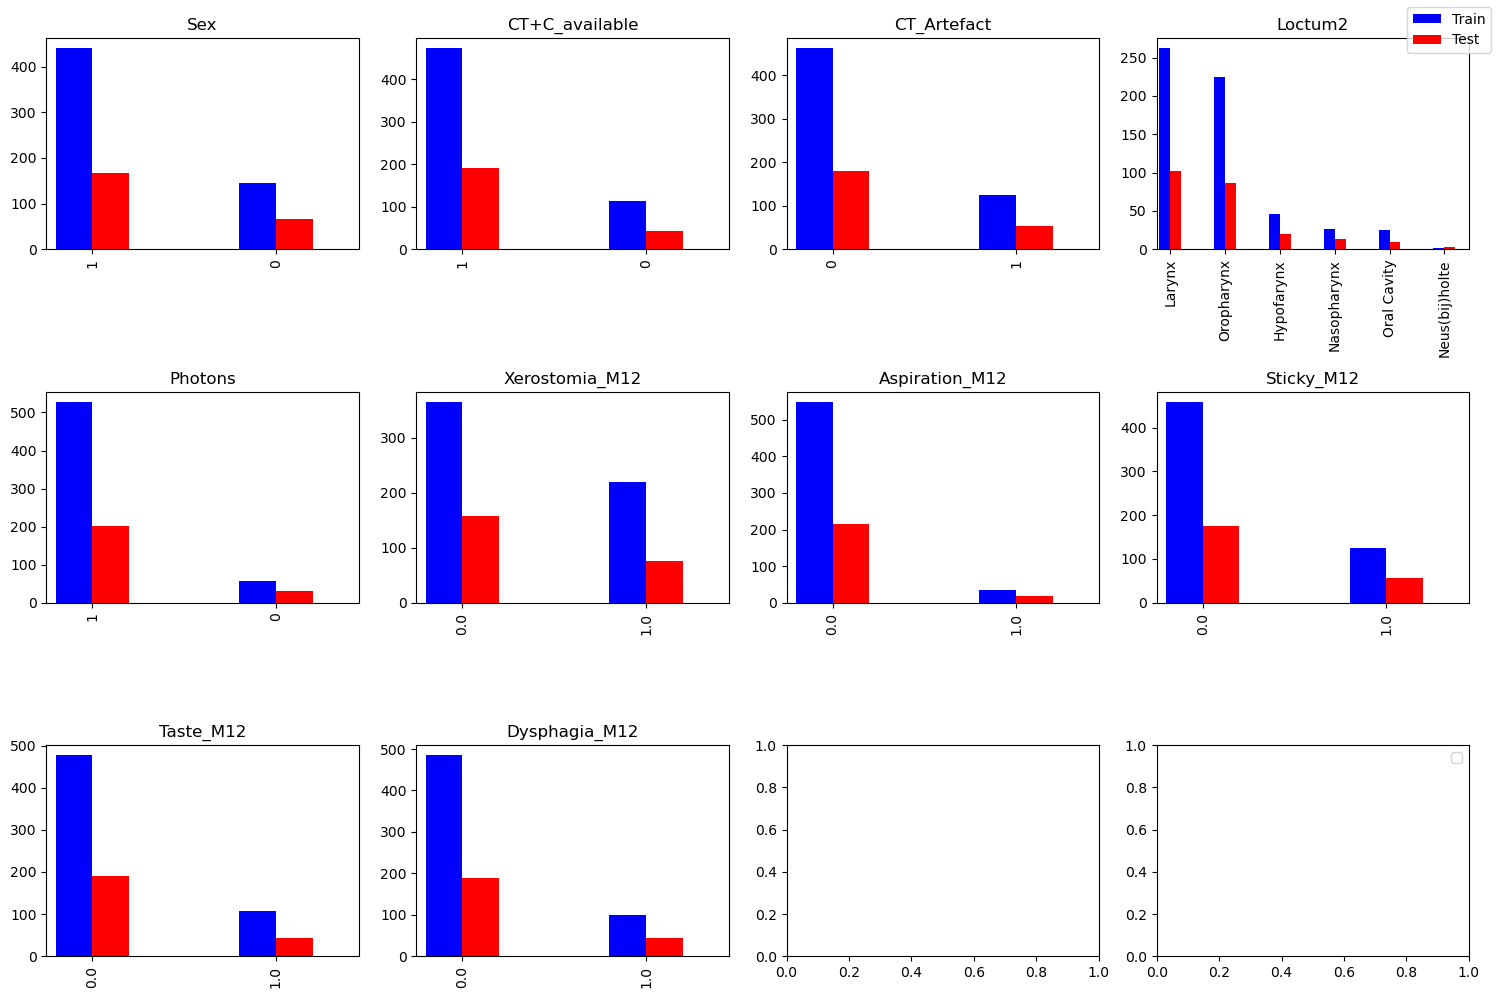

In [353]:
#train_StratColumns["Split"] = "train_val"
#test_StratColumns["Split"] = "test"
df_plot = pd.concat([train_StratColumns, test_StratColumns])


column_names = groups

cols = 4
rows = 3
bar_width = 0.2

fig,ax = plt.subplots(rows,cols,figsize=[15,10])
for i in range(len(column_names)):
    col_name = column_names[i]
    
    [row_idx, col_idx] = [int(i/cols),int(i % cols)]

    ax[row_idx, col_idx].set_title(col_name)
    
    # ascending=i makes it not sort the first feature (train_val and test)
    df_train_val[col_name].sort_values(ascending=True).value_counts(dropna=False).plot(kind='bar', ax=ax[row_idx, col_idx],  color='b', align='edge', width=-bar_width, label="Train")
    df_test[col_name].sort_values(ascending=True).value_counts(dropna=False).plot(kind='bar', ax=ax[row_idx, col_idx], color='r', align='edge', width=bar_width, label="Test")
    #ax[int(i/rows),int(i % rows)].axis('off')
    #ax[row_idx, col_idx].set_ylim([0, 500])
    ax[row_idx, col_idx].set_xlabel(None)

fig.tight_layout()
#fig.suptitle(title, fontsize = 13)
#plt.tight_layout()
#plt.savefig(label_images_save_dir + "/class_value_counts.png")
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.legend()
plt.show()

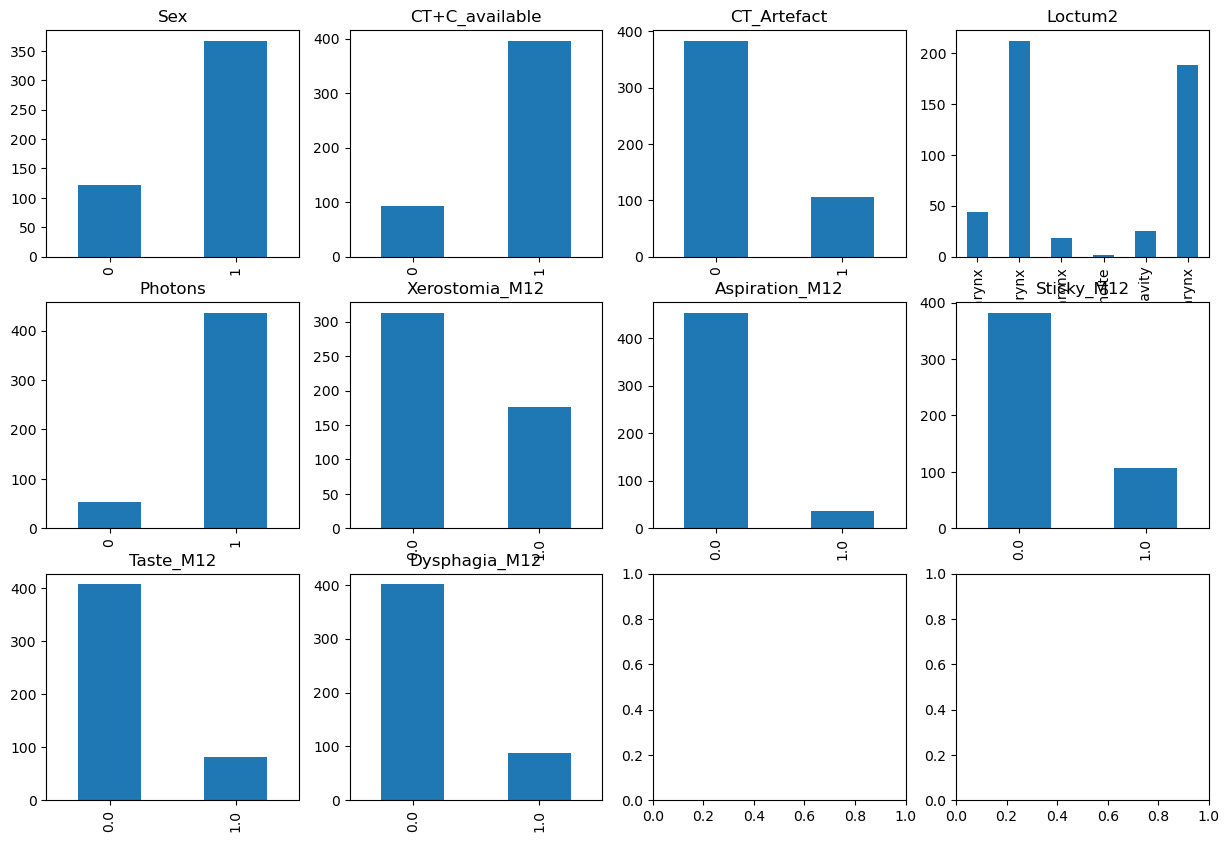

In [113]:

column_names = train_StratColumns.columns

cols = 4
rows = 3

fig,ax = plt.subplots(rows,cols,figsize=[15,10])
for i in range(len(column_names)):
    
    col_name = column_names[i]
    
    [row_idx, col_idx] = [int(i/cols),int(i % cols)]

    ax[row_idx, col_idx].set_title(col_name)
    

    # ascending=i makes it not sort the first feature (train_val and test)
    train_StratColumns[col_name].value_counts(dropna=False).sort_index(ascending=True).plot(kind='bar', ax=ax[row_idx, col_idx])
    #ax[int(i/rows),int(i % rows)].axis('off')
    #ax[row_idx, col_idx].set_ylim([0, 500])
    ax[row_idx, col_idx].set_xlabel(None)

    #ax[row_idx, col_idx].x(rotation=0, ha='right')



#fig.suptitle(title, fontsize = 13)
#plt.tight_layout()
#plt.savefig(label_images_save_dir + "/class_value_counts.png")
plt.show()